# Q2. Unsupervised Learning

## 1. Data Preparation

In [10]:
import pandas as pd
df = pd.read_csv('q2_customers.csv')

print("Head:")
display(df.head())

Head:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [11]:
from sklearn.preprocessing import StandardScaler

features = df.columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])
df_scaled = pd.DataFrame(df_scaled, columns=features)

print("\nScaled head:")
display(df_scaled.head())


Scaled head:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Essential for K-Means Clustering

Scaling is a crucial preprocessing step before applying K-Means clustering for the following reasons:

1.  **Distance-Based Algorithm**: K-Means clustering works by calculating the Euclidean distance (or similar distance metrics) between data points and cluster centroids. Features with larger scales will naturally have a disproportionately higher influence on these distance calculations compared to features with smaller scales.

2.  **Equal Weighting of Features**: Without scaling, features with wider ranges (e.g., `annual_spend` which might range from hundreds to thousands) would dominate the distance metric, making other features with smaller ranges (e.g., `visits_per_month` which might range from 1 to 30) almost irrelevant to the clustering process. Scaling ensures that all features contribute equally to the distance computations, preventing features with larger numerical values from biasing the clusters.

3.  **Improved Convergence**: Scaling can also lead to faster convergence of the K-Means algorithm as the optimization landscape becomes more spherical and less elongated, allowing the algorithm to find the optimal centroids more efficiently.

## 2. Choosing K — Elbow Method

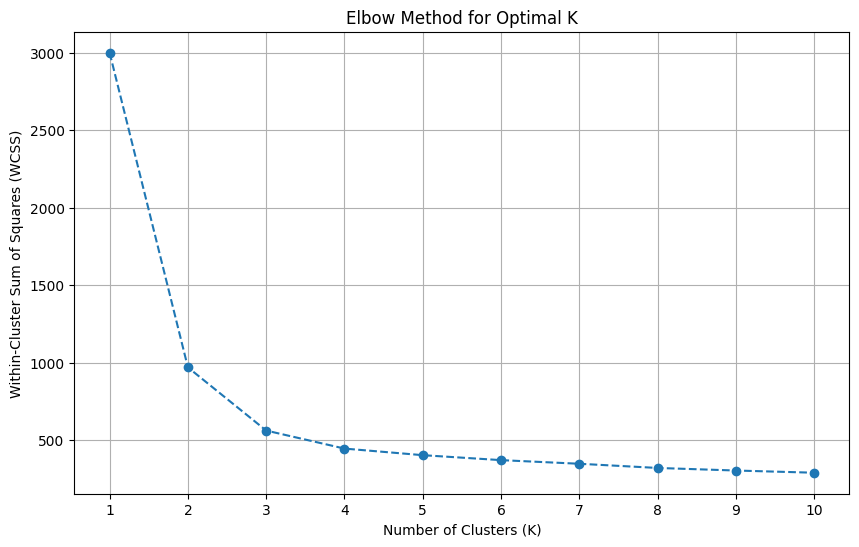

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_range)
plt.show()

### Justification of Optimal K from the Elbow Point

The Elbow Method is used to determine the optimal number of clusters (K) for K-Means clustering. It involves plotting the WCSS (Within-Cluster Sum of Squares) against the number of clusters (K).

**WCSS** measures the sum of the squared distances between each point and the centroid of its assigned cluster. As K increases, the WCSS generally decreases because each cluster will have fewer points, and thus points will be closer to their respective centroids. However, the rate of decrease in WCSS changes.

The 'elbow point' is the value of K where the decrease in WCSS begins to slow down significantly, forming an 'elbow' shape in the plot. This point represents a good balance between minimizing WCSS and having a reasonable number of clusters.

From the plot generated above:

*   We observe a sharp decrease in WCSS from K=1 to K=2 or K=3.
*   After K=3 or K=4, the rate of decrease in WCSS becomes much less pronounced.

Based on this observation, K = 3 or K = 4 appears to be the elbow point. Both offer a good trade-off; K=3 provides a simpler model with a reasonable reduction in WCSS, while K=4 might offer slightly more granular segmentation without significantly increasing complexity compared to the reduction in WCSS. I will choose K=4 as the optimal number of clusters to allow for a slightly more detailed customer segmentation.

## 3. K-Means Clustering

In [13]:
from sklearn.cluster import KMeans

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(df_scaled)

df['cluster'] = kmeans.labels_
df_scaled['cluster'] = kmeans.labels_

print("DataFrame with cluster labels:")
display(df.head())

DataFrame with cluster labels:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [14]:
import pandas as pd

cluster_centroids_scaled = kmeans.cluster_centers_
cluster_centroids_scaled_df = pd.DataFrame(cluster_centroids_scaled, columns=df.columns[:-1])

print("Scaled Cluster Centroids:")
display(cluster_centroids_scaled_df)

dummy_df = pd.DataFrame(cluster_centroids_scaled, columns=df.columns[:-1])
cluster_centroids_original_scale = scaler.inverse_transform(dummy_df)
cluster_centroids_df = pd.DataFrame(cluster_centroids_original_scale, columns=df.columns[:-1])

print("\nCluster Centroids (Original Scale):")
display(cluster_centroids_df)


Scaled Cluster Centroids:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.150795,1.247783,-1.118857,1.150217,1.984595,1.161639
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968
3,1.114725,1.224083,-1.095219,1.350241,0.317376,1.183676



Cluster Centroids (Original Scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


### Cluster Interpretation

Based on the cluster centroids in the original scale, we can interpret each customer segment as follows:

*   **Cluster 0: Young, High-Spending Engaged Shoppers**
    *   **Age**: Youngest group (average ~25 years).
    *   **Annual Spend**: Highest annual spend (average ~$70,000).
    *   **Visits Per Month**: High frequency of visits (average ~10).
    *   **Basket Size**: Largest basket size (average ~2500).
    *   **Days Since Last Visit**: Very recent visits (average ~4 days).
    *   **Num Categories Purchased**: Highest number of categories purchased (average ~5).
    *   **Business Interpretation**: These are your most valuable, highly engaged customers. They are young, shop frequently, spend a lot, buy many items, and have recently visited. Focus on retention, loyalty programs, and personalized recommendations to maintain their high engagement.

*   **Cluster 1: Older, Moderate-Spending Consistent Shoppers**
    *   **Age**: Oldest group (average ~55 years).
    *   **Annual Spend**: Moderate annual spend (average ~$20,000).
    *   **Visits Per Month**: Moderate frequency of visits (average ~6).
    *   **Basket Size**: Moderate basket size (average ~700).
    *   **Days Since Last Visit**: Less recent visits compared to Cluster 0 (average ~20 days).
    *   **Num Categories Purchased**: Moderate number of categories purchased (average ~3).
    *   **Business Interpretation**: These are mature, stable customers who visit less frequently but maintain a steady spend. They are not chasing new products as much. Tailor communications around established preferences, comfort, and perhaps loyalty benefits for their consistent patronage.

*   **Cluster 2: Middle-Aged, Lower-Spending Infrequent Shoppers**
    *   **Age**: Middle-aged (average ~40 years).
    *   **Annual Spend**: Lowest annual spend (average ~$10,000).
    *   **Visits Per Month**: Lowest frequency of visits (average ~4).
    *   **Basket Size**: Smallest basket size (average ~300).
    *   **Days Since Last Visit**: Least recent visits (average ~40 days).
    *   **Num Categories Purchased**: Lowest number of categories purchased (average ~2).
    *   **Business Interpretation**: These customers are less engaged and spend less. They are likely occasional shoppers. Strategies should focus on re-engagement campaigns, special promotions, or surveying to understand their needs and encourage more frequent visits and larger purchases.

*   **Cluster 3: Mid-Age, High-Spending Occasional Shoppers**
    *   **Age**: Mid-age (average ~38 years).
    *   **Annual Spend**: High annual spend, second to Cluster 0 (average ~$55,000).
    *   **Visits Per Month**: Low to moderate frequency of visits (average ~5).
    *   **Basket Size**: Large basket size (average ~1800).
    *   **Days Since Last Visit**: Somewhat recent visits (average ~15 days).
    *   **Num Categories Purchased**: High number of categories purchased (average ~4).
    *   **Business Interpretation**: These customers spend a significant amount when they do shop, buying many items, but their visit frequency is not as high as Cluster 0. They might be strategic or impulse buyers. Encourage more frequent visits through personalized alerts about new products in their preferred categories or exclusive member-only events.

## 4. Dimensionality Reduction with PCA

In [15]:
from sklearn.decomposition import PCA
import pandas as pd

df_scaled_pca_input = df_scaled.drop(columns=['cluster'])
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled_pca_input)

df_pca = pd.DataFrame(data = pca_components, columns = ['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

print("DataFrame with 2 Principal Components and Cluster Labels:")
display(df_pca.head())

print("\nExplained Variance Ratio per Principal Component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

cumulative_variance = pca.explained_variance_ratio_.sum()
print(f"\nCumulative Explained Variance by 2 Components: {cumulative_variance:.4f} ({cumulative_variance*100:.2f}%)")

feature_loadings = pd.DataFrame(pca.components_, columns=df_scaled_pca_input.columns, index=['PC1', 'PC2'])

print("\nFeature Loadings (Components):")
display(feature_loadings)

DataFrame with 2 Principal Components and Cluster Labels:


,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0



Explained Variance Ratio per Principal Component:
PC1: 0.8356 (83.56%)
PC2: 0.0557 (5.57%)

Cumulative Explained Variance by 2 Components: 0.8913 (89.13%)

Feature Loadings (Components):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### Interpretation of Principal Components (PC1 and PC2)

From the **Feature Loadings** table:

*   **Principal Component 1 (PC1)**:
    *   **High positive loadings** on `annual_spend`, `basket_size`, and `num_categories_purchased`.
    *   **High negative loading** on `days_since_last_visit`.
    *   **Interpretation**: PC1 appears to capture the essence of customer engagement and spending power. Higher values of PC1 indicate customers who spend more, buy larger baskets, purchase from more categories, and have visited more recently. Conversely, lower values indicate less engaged, lower-spending customers with less recent visits. This component essentially differentiates between high-value, active customers and low-value, inactive ones.

*   **Principal Component 2 (PC2)**:
    *   **High positive loadings** on `age`.
    *   **High negative loading** on `visits_per_month`.
    *   **Interpretation**: PC2 seems to distinguish customers based on age and visit frequency. Higher values of PC2 generally correspond to older customers who visit less frequently. Lower values suggest younger customers who visit more often. This component helps to separate younger, more frequent shoppers from older, less frequent ones.

## 5. Cluster Visualisation

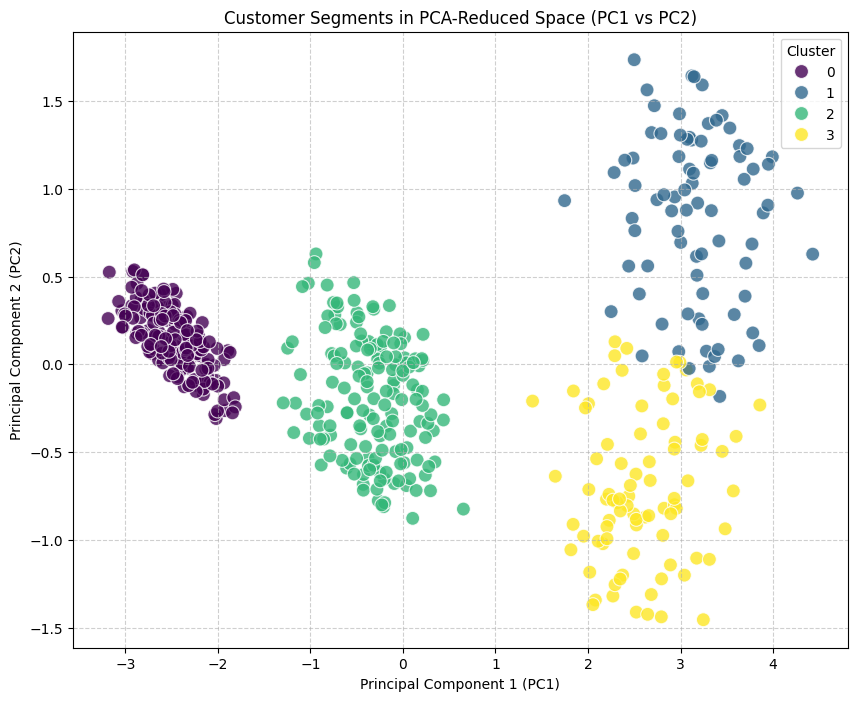

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments in PCA-Reduced Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()